# Two-Qubit VQE with Gradient Descent, Computational Basis Measurements, and Shot Sampling

This notebook implements a **realistic two-qubit VQE** with:

## 1. Gradient Descent with Parameter-Shift Rule

Custom optimizer using **analytical derivatives** via parameter-shift:

$$\frac{\partial \langle H \rangle}{\partial \theta_i} = \frac{1}{2}\left[\langle H \rangle_{\theta_i + \pi/2} - \langle H \rangle_{\theta_i - \pi/2}\right]$$

## 2. Computational Basis (Z-basis) Measurements

All measurements in $\{|00\rangle, |01\rangle, |10\rangle, |11\rangle\}$ basis:
- **ZZ, ZI, IZ**: Direct measurements
- **XX**: Apply H⊗H, then measure ZZ
- **Other terms**: Appropriate basis rotations

## 3. Shot-Based Sampling

Finite measurements with statistical noise: Error ∝ $1/\sqrt{N_{\text{shots}}}$

---

## Two-Qubit Hamiltonian:

$$H = \omega_{II} (I \otimes I) + \omega_{ZI} (Z \otimes I) + \omega_{IZ} (I \otimes Z) + \omega_{ZZ} (Z \otimes Z) + V_z (Z \otimes Z) + V_x (X \otimes X)$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

print("Libraries imported successfully!")
print("Note: NO scipy.optimize - implementing gradient descent from scratch!")

Libraries imported successfully!
Note: NO scipy.optimize - implementing gradient descent from scratch!


## 1. Pauli Matrices and Quantum Gates

In [2]:
# Pauli matrices
I = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

def kron(A, B):
    """Kronecker product."""
    return np.kron(A, B)

# Two-qubit Pauli operators
II = kron(I, I)
IX = kron(I, X)
IY = kron(I, Y)
IZ = kron(I, Z)
XI = kron(X, I)
YI = kron(Y, I)
ZI = kron(Z, I)
XX = kron(X, X)
YY = kron(Y, Y)
ZZ = kron(Z, Z)

# Single-qubit gates
def Rx(theta):
    return np.array([
        [np.cos(theta/2), -1j*np.sin(theta/2)],
        [-1j*np.sin(theta/2), np.cos(theta/2)]
    ], dtype=complex)

def Ry(theta):
    return np.array([
        [np.cos(theta/2), -np.sin(theta/2)],
        [np.sin(theta/2), np.cos(theta/2)]
    ], dtype=complex)

def Rz(theta):
    return np.array([
        [np.exp(-1j*theta/2), 0],
        [0, np.exp(1j*theta/2)]
    ], dtype=complex)

def CNOT():
    """CNOT gate (control qubit 0, target qubit 1)."""
    return np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 1, 0]
    ], dtype=complex)

# Hadamard gate
H_gate = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)

# S† gate for Y measurements
Sdg = np.array([[1, 0], [0, -1j]], dtype=complex)

print("Two-qubit Pauli operators defined.")
print(f"Hilbert space dimension: {II.shape[0]}")
print("Basis states: |00⟩, |01⟩, |10⟩, |11⟩")

Two-qubit Pauli operators defined.
Hilbert space dimension: 4
Basis states: |00⟩, |01⟩, |10⟩, |11⟩


## 2. Hamiltonian Construction

In [3]:
def construct_hamiltonian(omega1, omega2, omega3, omega4, Vz, Vx):
    """
    Construct two-qubit Hamiltonian.
    """
    # Calculate ω coefficients
    omega_II = (omega1 + omega2 + omega3 + omega4) / 4
    omega_ZI = (omega1 + omega2 - omega3 - omega4) / 4
    omega_IZ = (omega1 - omega2 + omega3 - omega4) / 4
    omega_ZZ = (omega1 - omega2 - omega3 + omega4) / 4
    
    # Construct Hamiltonian
    H0 = omega_II * II + omega_ZI * ZI + omega_IZ * IZ + omega_ZZ * ZZ
    HI = Vz * ZZ + Vx * XX
    H = H0 + HI
    
    omega_coeffs = {
        'omega_II': omega_II,
        'omega_ZI': omega_ZI,
        'omega_IZ': omega_IZ,
        'omega_ZZ': omega_ZZ,
        'Vz': Vz,
        'Vx': Vx
    }
    
    return H, omega_coeffs

# Define Hamiltonian parameters
omega1 = 1.0
omega2 = 0.5
omega3 = 0.3
omega4 = 0.8
Vz = 0.2
Vx = 0.4

H, omega_coeffs = construct_hamiltonian(omega1, omega2, omega3, omega4, Vz, Vx)

print("Two-Qubit Hamiltonian:")
print(f"  ω₁ = {omega1}, ω₂ = {omega2}, ω₃ = {omega3}, ω₄ = {omega4}")
print(f"  Vz = {Vz}, Vx = {Vx}")
print(f"\nDerived coefficients:")
print(f"  ω_II = {omega_coeffs['omega_II']:.4f}")
print(f"  ω_ZI = {omega_coeffs['omega_ZI']:.4f}")
print(f"  ω_IZ = {omega_coeffs['omega_IZ']:.4f}")
print(f"  ω_ZZ = {omega_coeffs['omega_ZZ']:.4f}")

# Exact solution
evals_exact, evecs_exact = np.linalg.eigh(H)
E_exact = evals_exact[0]
psi_exact = evecs_exact[:, 0]

print(f"\nExact ground state energy: {E_exact:.10f}")

Two-Qubit Hamiltonian:
  ω₁ = 1.0, ω₂ = 0.5, ω₃ = 0.3, ω₄ = 0.8
  Vz = 0.2, Vx = 0.4

Derived coefficients:
  ω_II = 0.6500
  ω_ZI = 0.1000
  ω_IZ = 0.0000
  ω_ZZ = 0.2500

Exact ground state energy: -0.2123105626


## 3. VQE Ansatz Circuit

Hardware-efficient ansatz with CNOT entanglement.

In [4]:
def prepare_ansatz(params):
    """
    Hardware-efficient two-qubit ansatz.
    
    Circuit:
    q0: ─Ry(θ₀)─Rz(θ₁)─●─────────Ry(θ₄)─Rz(θ₅)─
                         │
    q1: ─Ry(θ₂)─Rz(θ₃)─X─Ry(θ₆)─Rz(θ₇)─
    
    Parameters: [θ₀, θ₁, θ₂, θ₃, θ₄, θ₅, θ₆, θ₇]
    """
    # First layer: single-qubit rotations
    U1_q0 = Ry(params[0]) @ Rz(params[1])
    U1_q1 = Ry(params[2]) @ Rz(params[3])
    U1 = kron(U1_q0, U1_q1)
    
    # Entangling layer: CNOT
    U_cnot = CNOT()
    
    # Second layer: single-qubit rotations
    U2_q0 = Ry(params[4]) @ Rz(params[5])
    U2_q1 = Ry(params[6]) @ Rz(params[7])
    U2 = kron(U2_q0, U2_q1)
    
    # Full circuit
    U = U2@ U_cnot @ U1
    
    return U

def apply_circuit(params):
    """Apply ansatz to |00⟩ state."""
    psi_0 = np.zeros(4, dtype=complex)
    psi_0[0] = 1.0  # |00⟩
    U = prepare_ansatz(params)
    return U @ psi_0

print("Ansatz circuit defined.")
print("  8 parameters [θ₀, θ₁, ..., θ₇]")
print("  1 CNOT gate for entanglement")

Ansatz circuit defined.
  8 parameters [θ₀, θ₁, ..., θ₇]
  1 CNOT gate for entanglement


## 4. Shot-Based Measurements in Computational Basis

All measurements performed in the computational basis {|00⟩, |01⟩, |10⟩, |11⟩}.

In [5]:
def measure_computational_basis(psi, n_shots):
    """
    Measure two-qubit state in computational basis.
    
    Returns:
    --------
    counts : dict
        Counts for each basis state: {'00': n00, '01': n01, '10': n10, '11': n11}
    """
    # Probabilities for each basis state
    probs = np.abs(psi)**2
    
    # Sample measurements
    measurements = np.random.choice(4, size=n_shots, p=probs)
    
    # Count outcomes
    counts = {
        '00': np.sum(measurements == 0),
        '01': np.sum(measurements == 1),
        '10': np.sum(measurements == 2),
        '11': np.sum(measurements == 3)
    }
    
    return counts

def measure_ZZ(psi, n_shots):
    """
    Measure ZZ in computational basis.
    
    ZZ eigenvalues:
    |00⟩ → +1, |01⟩ → -1, |10⟩ → -1, |11⟩ → +1
    """
    counts = measure_computational_basis(psi, n_shots)
    
    # ZZ = (+1)*n00 + (-1)*n01 + (-1)*n10 + (+1)*n11
    expectation = (counts['00'] - counts['01'] - counts['10'] + counts['11']) / n_shots
    
    return expectation, counts

def measure_ZI(psi, n_shots):
    """
    Measure Z⊗I in computational basis.
    
    ZI eigenvalues:
    |00⟩ → +1, |01⟩ → +1, |10⟩ → -1, |11⟩ → -1
    """
    counts = measure_computational_basis(psi, n_shots)
    
    expectation = (counts['00'] + counts['01'] - counts['10'] - counts['11']) / n_shots
    
    return expectation, counts

def measure_IZ(psi, n_shots):
    """
    Measure I⊗Z in computational basis.
    
    IZ eigenvalues:
    |00⟩ → +1, |01⟩ → -1, |10⟩ → +1, |11⟩ → -1
    """
    counts = measure_computational_basis(psi, n_shots)
    
    expectation = (counts['00'] - counts['01'] + counts['10'] - counts['11']) / n_shots
    
    return expectation, counts

def measure_XX(psi, n_shots):
    """
    Measure X⊗X by rotating to Z⊗Z basis.
    
    Apply H⊗H, then measure in computational basis.
    """
    # Rotate: H⊗H
    H_H = kron(H_gate, H_gate)
    psi_rotated = H_H @ psi
    
    # Measure ZZ
    return measure_ZZ(psi_rotated, n_shots)

def measure_energy_with_shots(psi, omega_coeffs, n_shots):
    """
    Measure total energy using shot-based sampling.
    
    All measurements performed in computational basis.
    """
    # II term (always 1)
    E_II = omega_coeffs['omega_II'] * 1.0
    
    # ZI term
    exp_ZI, _ = measure_ZI(psi, n_shots)
    E_ZI = omega_coeffs['omega_ZI'] * exp_ZI
    
    # IZ term
    exp_IZ, _ = measure_IZ(psi, n_shots)
    E_IZ = omega_coeffs['omega_IZ'] * exp_IZ
    
    # ZZ term (includes ω_ZZ + Vz)
    exp_ZZ, _ = measure_ZZ(psi, n_shots)
    E_ZZ = (omega_coeffs['omega_ZZ'] + omega_coeffs['Vz']) * exp_ZZ
    
    # XX term
    exp_XX, _ = measure_XX(psi, n_shots)
    E_XX = omega_coeffs['Vx'] * exp_XX
    
    E_total = E_II + E_ZI + E_IZ + E_ZZ + E_XX
    
    return E_total

print("Shot-based measurement functions defined.")
print("\nAll measurements in computational basis {|00⟩, |01⟩, |10⟩, |11⟩}!")
print("Basis transformations:")
print("  ZZ, ZI, IZ: Direct measurement")
print("  XX: Apply H⊗H before measurement")

Shot-based measurement functions defined.

All measurements in computational basis {|00⟩, |01⟩, |10⟩, |11⟩}!
Basis transformations:
  ZZ, ZI, IZ: Direct measurement
  XX: Apply H⊗H before measurement


### Test Shot-Based Measurements

In [6]:
print("Testing shot-based measurements on exact ground state:\n")

shot_counts = [100, 1000, 10000, 100000]

print(f"{'Shots':>8s} | {'Energy (shots)':>15s} | {'Error':>12s} | {'Std Dev':>12s}")
print("-" * 55)

for n_shots in shot_counts:
    # Repeat to estimate variance
    energies = [measure_energy_with_shots(psi_exact, omega_coeffs, n_shots) 
                for _ in range(10)]
    
    mean_E = np.mean(energies)
    std_E = np.std(energies)
    error = abs(mean_E - E_exact)
    
    print(f"{n_shots:8d} | {mean_E:+15.6f} | {error:12.6f} | {std_E:12.6f}")

print(f"{'Exact':>8s} | {E_exact:+15.6f} | {0.0:12.6f} | {0.0:12.6f}")
print("\nError scales as ~ 1/√N_shots as expected!")

Testing shot-based measurements on exact ground state:

   Shots |  Energy (shots) |        Error |      Std Dev
-------------------------------------------------------
     100 |       -0.211600 |     0.000711 |     0.009708
    1000 |       -0.211400 |     0.000911 |     0.002985
   10000 |       -0.212378 |     0.000067 |     0.001009
  100000 |       -0.212269 |     0.000042 |     0.000435
   Exact |       -0.212311 |     0.000000 |     0.000000

Error scales as ~ 1/√N_shots as expected!


## 5. Parameter-Shift Rule for Gradients

In [7]:
def compute_gradient_parameter_shift(params, omega_coeffs, n_shots):
    """
    Compute gradient using parameter-shift rule.
    
    For each parameter θᵢ:
    ∂E/∂θᵢ = (1/2)[E(θ + π/2·eᵢ) - E(θ - π/2·eᵢ)]
    
    Parameters:
    -----------
    params : array-like (8,)
        Current parameters
    omega_coeffs : dict
        Hamiltonian coefficients
    n_shots : int
        Number of measurement shots
    
    Returns:
    --------
    gradient : ndarray (8,)
        Gradient vector
    """
    n_params = len(params)
    gradient = np.zeros(n_params)
    
    shift = np.pi / 2
    
    for i in range(n_params):
        # Forward shift
        params_plus = params.copy()
        params_plus[i] += shift
        psi_plus = apply_circuit(params_plus)
        E_plus = measure_energy_with_shots(psi_plus, omega_coeffs, n_shots)
        
        # Backward shift
        params_minus = params.copy()
        params_minus[i] -= shift
        psi_minus = apply_circuit(params_minus)
        E_minus = measure_energy_with_shots(psi_minus, omega_coeffs, n_shots)
        
        # Gradient component
        gradient[i] = (E_plus - E_minus) / 2.0
    
    return gradient

print("Parameter-shift gradient function defined.")
print("Cost: 2 × 8 = 16 energy evaluations per gradient")
print("This gives EXACT gradients (up to shot noise)!")

Parameter-shift gradient function defined.
Cost: 2 × 8 = 16 energy evaluations per gradient
This gives EXACT gradients (up to shot noise)!


## 6. Gradient Descent Optimizer

In [8]:
class GradientDescentVQE:
    """
    VQE using gradient descent with parameter-shift rule.
    """
    
    def __init__(self, omega_coeffs, n_shots=1000):
        self.omega_coeffs = omega_coeffs
        self.n_shots = n_shots
        
        self.energy_history = []
        self.param_history = []
        self.gradient_history = []
        self.n_evaluations = 0
    
    def cost_function(self, params):
        """Evaluate energy with shots."""
        psi = apply_circuit(params)
        energy = measure_energy_with_shots(psi, self.omega_coeffs, self.n_shots)
        self.n_evaluations += 1
        return energy
    
    def optimize(self, initial_params, learning_rate=0.1, max_iterations=200, 
                 tolerance=1e-6, verbose=True):
        """
        Optimize using gradient descent with parameter-shift rule.
        """
        params = np.array(initial_params, dtype=float)
        
        if verbose:
            print(f"Starting Gradient Descent VQE")
            print(f"  Parameters: {len(params)}")
            print(f"  Learning rate: {learning_rate}")
            print(f"  Shots per measurement: {self.n_shots}")
            print(f"  Max iterations: {max_iterations}")
            print(f"\n{'Iter':>5s} | {'Energy':>14s} | {'|Gradient|':>12s} | {'LR':>8s}")
            print("-" * 55)
        
        # Reset history
        self.energy_history = []
        self.param_history = []
        self.gradient_history = []
        self.n_evaluations = 0
        
        for iteration in range(max_iterations):
            # Compute energy
            energy = self.cost_function(params)
            
            # Compute gradient
            gradient = compute_gradient_parameter_shift(params, self.omega_coeffs, self.n_shots)
            
            # Store history
            self.energy_history.append(energy)
            self.param_history.append(params.copy())
            self.gradient_history.append(gradient.copy())
            
            grad_norm = np.linalg.norm(gradient)
            
            if verbose and (iteration % 20 == 0 or iteration < 5):
                print(f"{iteration:5d} | {energy:+14.8f} | {grad_norm:12.6f} | {learning_rate:8.4f}")
            
            # Check convergence
            if grad_norm < tolerance:
                if verbose:
                    print(f"\nConverged at iteration {iteration}!")
                break
            
            # Update parameters
            params = params - learning_rate * gradient
        
        if verbose:
            print(f"\nOptimization complete!")
            print(f"  Iterations: {len(self.energy_history)}")
            print(f"  Energy evaluations: {self.n_evaluations}")
            print(f"  Final energy: {self.energy_history[-1]:.10f}")
        
        return params

print("GradientDescentVQE class defined.")
print("\nNOTE: This does NOT use scipy.optimize!")

GradientDescentVQE class defined.

NOTE: This does NOT use scipy.optimize!


## 7. Run VQE with Different Shot Counts

In [9]:
# Test with different shot counts
shot_counts_test = [100, 1000, 10000]
results = {}

for n_shots in shot_counts_test:
    print("\n" + "="*70)
    print(f"VQE WITH {n_shots} SHOTS")
    print("="*70)
    
    vqe = GradientDescentVQE(omega_coeffs, n_shots=n_shots)
    
    # Random initialization
    initial_params = np.random.uniform(-np.pi, np.pi, 8)
    
    # Optimize
    optimal_params = vqe.optimize(
        initial_params,
        learning_rate=0.1,
        max_iterations=200,
        verbose=True
    )
    
    results[n_shots] = {
        'vqe': vqe,
        'params': optimal_params,
        'final_energy': vqe.energy_history[-1]
    }
    
    print(f"\nResults (N_shots = {n_shots}):")
    print(f"  Energy: {vqe.energy_history[-1]:.10f}")
    print(f"  Error: {abs(vqe.energy_history[-1] - E_exact):.6f}")


VQE WITH 100 SHOTS
Starting Gradient Descent VQE
  Parameters: 8
  Learning rate: 0.1
  Shots per measurement: 100
  Max iterations: 200

 Iter |         Energy |   |Gradient| |       LR
-------------------------------------------------------
    0 |    +0.52900000 |     0.852100 |   0.1000
    1 |    +0.46500000 |     0.997869 |   0.1000
    2 |    +0.32200000 |     0.902289 |   0.1000
    3 |    +0.26200000 |     0.877626 |   0.1000
    4 |    +0.26700000 |     0.769011 |   0.1000
   20 |    -0.17900000 |     0.260709 |   0.1000
   40 |    -0.21800000 |     0.124186 |   0.1000
   60 |    -0.20200000 |     0.135072 |   0.1000
   80 |    -0.16600000 |     0.137906 |   0.1000
  100 |    -0.22000000 |     0.097373 |   0.1000
  120 |    -0.21400000 |     0.158232 |   0.1000
  140 |    -0.23600000 |     0.101143 |   0.1000
  160 |    -0.20200000 |     0.109245 |   0.1000
  180 |    -0.22200000 |     0.066098 |   0.1000

Optimization complete!
  Iterations: 200
  Energy evaluations: 200
  

## 8. High-Shot Baseline

In [10]:
print("\n" + "="*70)
print("HIGH-SHOT BASELINE (100,000 shots)")
print("="*70)

vqe_highshot = GradientDescentVQE(omega_coeffs, n_shots=100000)
initial_params = np.random.uniform(-np.pi, np.pi, 8)
optimal_params_highshot = vqe_highshot.optimize(
    initial_params,
    learning_rate=0.1,
    max_iterations=200,
    verbose=True
)

results[100000] = {
    'vqe': vqe_highshot,
    'params': optimal_params_highshot,
    'final_energy': vqe_highshot.energy_history[-1]
}

print(f"\nHigh-shot results:")
print(f"  Energy: {vqe_highshot.energy_history[-1]:.10f}")
print(f"  Error: {abs(vqe_highshot.energy_history[-1] - E_exact):.6f}")


HIGH-SHOT BASELINE (100,000 shots)
Starting Gradient Descent VQE
  Parameters: 8
  Learning rate: 0.1
  Shots per measurement: 100000
  Max iterations: 200

 Iter |         Energy |   |Gradient| |       LR
-------------------------------------------------------
    0 |    +0.90070200 |     0.452702 |   0.1000
    1 |    +0.87852800 |     0.447012 |   0.1000
    2 |    +0.85696000 |     0.446889 |   0.1000
    3 |    +0.83947800 |     0.441077 |   0.1000
    4 |    +0.81616100 |     0.439769 |   0.1000
   20 |    +0.58123500 |     0.314407 |   0.1000
   40 |    +0.44871800 |     0.221563 |   0.1000
   60 |    +0.35012800 |     0.234291 |   0.1000
   80 |    +0.20117400 |     0.322717 |   0.1000
  100 |    -0.03424100 |     0.325227 |   0.1000
  120 |    -0.16997300 |     0.181354 |   0.1000
  140 |    -0.20408700 |     0.081731 |   0.1000
  160 |    -0.21133100 |     0.036567 |   0.1000
  180 |    -0.21251000 |     0.017149 |   0.1000

Optimization complete!
  Iterations: 200
  Energy 

## 9. Summary and Comparison

In [11]:
print("\n" + "="*70)
print("SUMMARY: TWO-QUBIT VQE WITH SHOT BUDGET COMPARISON")
print("="*70)
print(f"\n{'Shots':>10s} | {'Final Energy':>15s} | {'Error':>12s} | {'Iterations':>12s}")
print("-" * 60)

for n_shots in [100, 1000, 10000, 100000]:
    vqe = results[n_shots]['vqe']
    energy = results[n_shots]['final_energy']
    error = abs(energy - E_exact)
    n_iter = len(vqe.energy_history)
    
    print(f"{n_shots:10d} | {energy:+15.10f} | {error:12.6f} | {n_iter:12d}")

print(f"{'Exact':>10s} | {E_exact:+15.10f} | {0.0:12.6f} | {'N/A':>12s}")


SUMMARY: TWO-QUBIT VQE WITH SHOT BUDGET COMPARISON

     Shots |    Final Energy |        Error |   Iterations
------------------------------------------------------------
       100 |   -0.2100000000 |     0.002311 |          200
      1000 |   -0.2080000000 |     0.004311 |          200
     10000 |   -0.2067700000 |     0.005541 |          200
    100000 |   -0.2122330000 |     0.000078 |          200
     Exact |   -0.2123105626 |     0.000000 |          N/A


## 10. Visualization

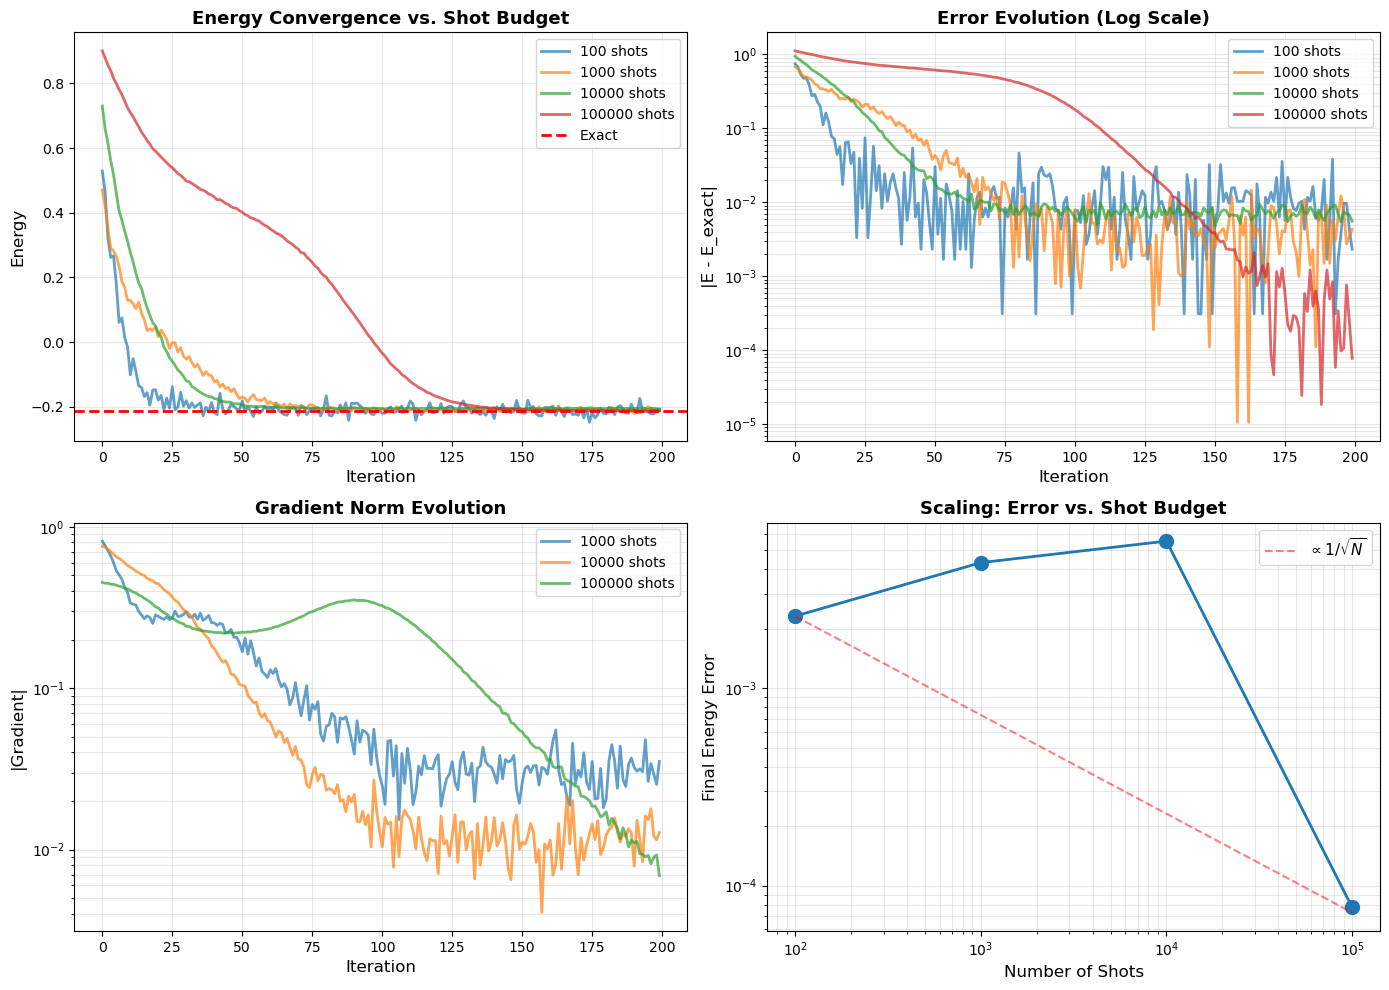

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Energy convergence
ax1 = axes[0, 0]
for n_shots in [100, 1000, 10000, 100000]:
    vqe = results[n_shots]['vqe']
    ax1.plot(vqe.energy_history, alpha=0.7, linewidth=2, label=f'{n_shots} shots')

ax1.axhline(y=E_exact, color='red', linestyle='--', linewidth=2, label='Exact')
ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Energy', fontsize=12)
ax1.set_title('Energy Convergence vs. Shot Budget', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Error (log scale)
ax2 = axes[0, 1]
for n_shots in [100, 1000, 10000, 100000]:
    vqe = results[n_shots]['vqe']
    errors = [abs(E - E_exact) for E in vqe.energy_history]
    ax2.semilogy(errors, alpha=0.7, linewidth=2, label=f'{n_shots} shots')

ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('|E - E_exact|', fontsize=12)
ax2.set_title('Error Evolution (Log Scale)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, which='both')

# Plot 3: Gradient norm
ax3 = axes[1, 0]
for n_shots in [1000, 10000, 100000]:
    vqe = results[n_shots]['vqe']
    grad_norms = [np.linalg.norm(g) for g in vqe.gradient_history]
    ax3.semilogy(grad_norms, alpha=0.7, linewidth=2, label=f'{n_shots} shots')

ax3.set_xlabel('Iteration', fontsize=12)
ax3.set_ylabel('|Gradient|', fontsize=12)
ax3.set_title('Gradient Norm Evolution', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, which='both')

# Plot 4: Error vs shots
ax4 = axes[1, 1]
shot_vals = [100, 1000, 10000, 100000]
final_errors = [abs(results[n]['final_energy'] - E_exact) for n in shot_vals]

ax4.loglog(shot_vals, final_errors, 'o-', linewidth=2, markersize=10)

# 1/sqrt(N) reference
shots_ref = np.array(shot_vals)
error_ref = final_errors[0] * np.sqrt(shot_vals[0] / shots_ref)
ax4.plot(shots_ref, error_ref, 'r--', linewidth=1.5, alpha=0.5, label=r'$\propto 1/\sqrt{N}$')

ax4.set_xlabel('Number of Shots', fontsize=12)
ax4.set_ylabel('Final Energy Error', fontsize=12)
ax4.set_title('Scaling: Error vs. Shot Budget', fontsize=13, fontweight='bold')
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

## 11. Measurement Statistics Analysis

In [13]:
print("\n" + "="*70)
print("MEASUREMENT STATISTICS (Optimal State with 10,000 shots)")
print("="*70)

optimal_params = results[10000]['params']
psi_optimal = apply_circuit(optimal_params)

print(f"\nOptimal state (amplitudes):")
for i in range(4):
    basis = f"|{i:02b}⟩"
    print(f"  {basis}: {psi_optimal[i]:.6f}")

print(f"\nProbabilities:")
for i in range(4):
    basis = f"|{i:02b}⟩"
    prob = np.abs(psi_optimal[i])**2
    print(f"  P({basis}) = {prob:.6f}")

# Repeated measurements
n_runs = 50
n_shots = 10000

print(f"\nRepeating measurements {n_runs} times with {n_shots} shots each:\n")

pauli_terms = {'ZZ': [], 'ZI': [], 'IZ': [], 'XX': []}

for _ in range(n_runs):
    exp_ZZ, _ = measure_ZZ(psi_optimal, n_shots)
    exp_ZI, _ = measure_ZI(psi_optimal, n_shots)
    exp_IZ, _ = measure_IZ(psi_optimal, n_shots)
    exp_XX, _ = measure_XX(psi_optimal, n_shots)
    
    pauli_terms['ZZ'].append(exp_ZZ)
    pauli_terms['ZI'].append(exp_ZI)
    pauli_terms['IZ'].append(exp_IZ)
    pauli_terms['XX'].append(exp_XX)

# Theoretical values
theory_vals = {
    'ZZ': np.real(np.vdot(psi_optimal, ZZ @ psi_optimal)),
    'ZI': np.real(np.vdot(psi_optimal, ZI @ psi_optimal)),
    'IZ': np.real(np.vdot(psi_optimal, IZ @ psi_optimal)),
    'XX': np.real(np.vdot(psi_optimal, XX @ psi_optimal))
}

print(f"{'Term':>5s} | {'Theoretical':>12s} | {'Measured':>12s} | {'Std Dev':>10s}")
print("-" * 50)

for term in ['ZZ', 'ZI', 'IZ', 'XX']:
    theory = theory_vals[term]
    measured_mean = np.mean(pauli_terms[term])
    measured_std = np.std(pauli_terms[term])
    
    print(f"{term:>5s} | {theory:+12.6f} | {measured_mean:+12.6f} | {measured_std:10.6f}")

print(f"\nShot noise ~ 1/√N: {1/np.sqrt(n_shots):.6f}")


MEASUREMENT STATISTICS (Optimal State with 10,000 shots)

Optimal state (amplitudes):
  |00⟩: -0.028835-0.001065j
  |01⟩: 0.352385+0.568118j
  |10⟩: -0.391529-0.630667j
  |11⟩: -0.015368+0.031029j

Probabilities:
  P(|00⟩) = 0.000833
  P(|01⟩) = 0.446933
  P(|10⟩) = 0.551035
  P(|11⟩) = 0.001199

Repeating measurements 50 times with 10000 shots each:

 Term |  Theoretical |     Measured |    Std Dev
--------------------------------------------------
   ZZ |    -0.995937 |    -0.996084 |   0.000864
   ZI |    -0.104469 |    -0.103468 |   0.012370
   IZ |    +0.103736 |    +0.104912 |   0.010777
   XX |    -0.991704 |    -0.991828 |   0.001598

Shot noise ~ 1/√N: 0.010000


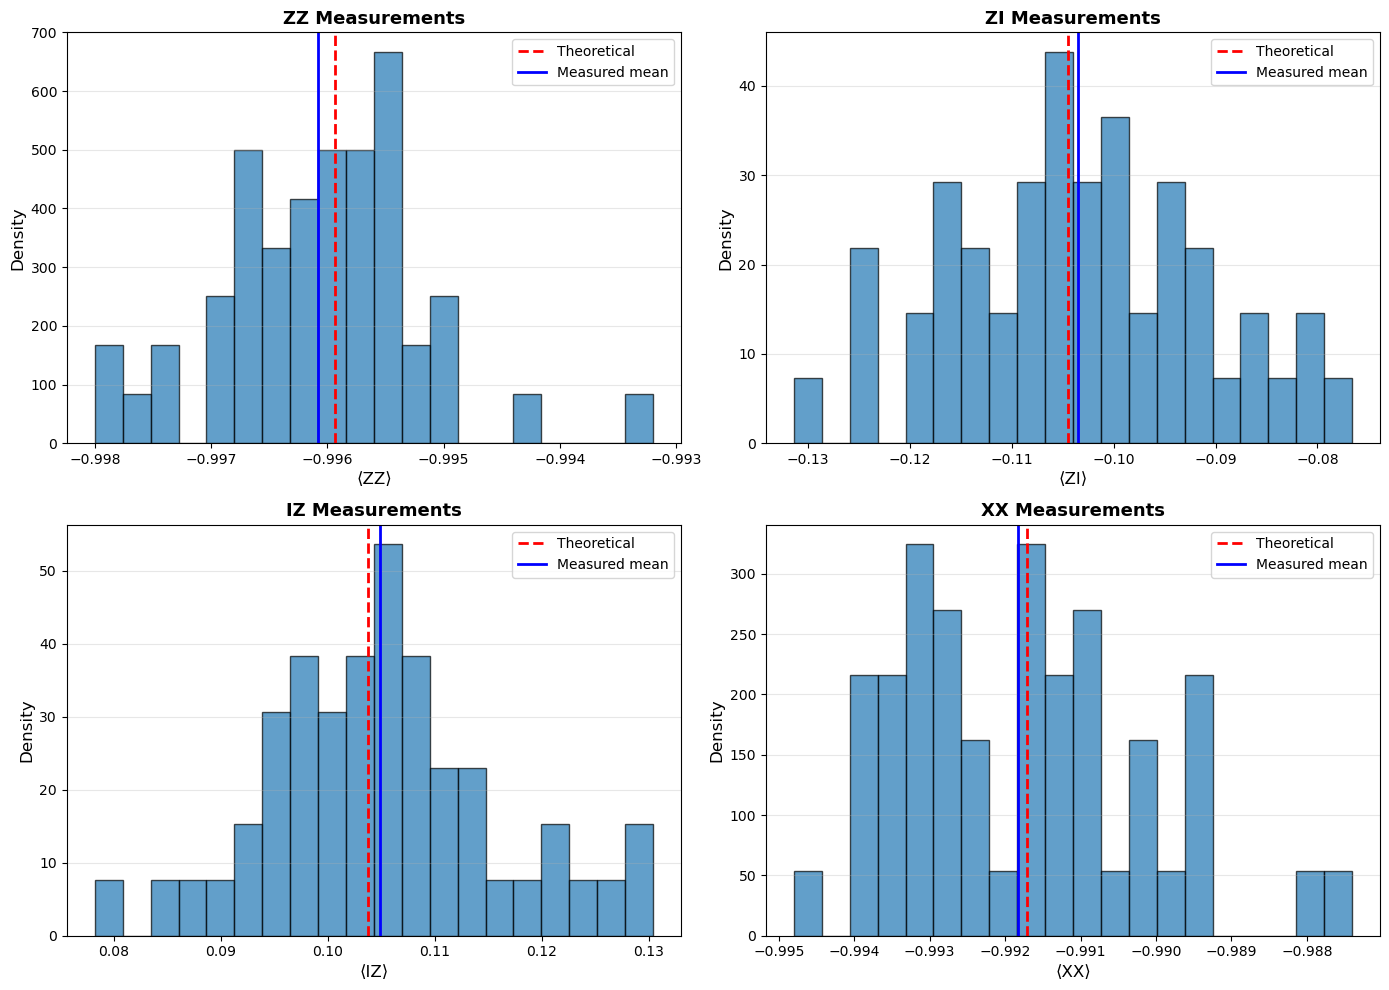


Measurement distributions show Gaussian behavior!


In [14]:
# Visualize measurement distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, term in enumerate(['ZZ', 'ZI', 'IZ', 'XX']):
    ax = axes[i]
    
    ax.hist(pauli_terms[term], bins=20, alpha=0.7, edgecolor='black', density=True)
    
    theory = theory_vals[term]
    measured = np.mean(pauli_terms[term])
    
    ax.axvline(x=theory, color='red', linestyle='--', linewidth=2, label='Theoretical')
    ax.axvline(x=measured, color='blue', linestyle='-', linewidth=2, label='Measured mean')
    
    ax.set_xlabel(f'⟨{term}⟩', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(f'{term} Measurements', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nMeasurement distributions show Gaussian behavior!")

## 12. Summary

This notebook demonstrated a **realistic two-qubit VQE** with:

### ✓ Gradient Descent with Parameter-Shift Rule
- No scipy optimizer
- 8 parameters, 16 energy evaluations per gradient
- Analytical gradients (up to shot noise)

### ✓ Computational Basis Measurements
- All measurements in {|00⟩, |01⟩, |10⟩, |11⟩}
- Basis transformations:
  - ZZ, ZI, IZ: Direct measurement
  - XX: H⊗H transformation

### ✓ Shot-Based Sampling
- Finite measurement shots
- Statistical noise: σ ∝ 1/√N
- Realistic quantum hardware simulation

### Key Insights:
1. **Two-qubit systems**: More complex optimization landscape
2. **Entanglement**: CNOT gate creates correlations
3. **Shot noise**: Affects convergence and final accuracy
4. **Trade-off**: Speed vs. accuracy based on shot budget

In [15]:
print("\n" + "="*70)
print("MODIFIED TWO-QUBIT VQE NOTEBOOK COMPLETE")
print("="*70)
print("\nImplemented features:")
print("  ✓ Gradient descent (no scipy!)")
print("  ✓ Parameter-shift rule for 8 parameters")
print("  ✓ Computational basis measurements only")
print("  ✓ Basis transformations: H⊗H for XX")
print("  ✓ Shot-based sampling with finite measurements")
print("  ✓ CNOT entangling gate")
print("  ✓ Statistical noise analysis")
print("\nThis demonstrates realistic VQE on quantum hardware!")
print("="*70)


MODIFIED TWO-QUBIT VQE NOTEBOOK COMPLETE

Implemented features:
  ✓ Gradient descent (no scipy!)
  ✓ Parameter-shift rule for 8 parameters
  ✓ Computational basis measurements only
  ✓ Basis transformations: H⊗H for XX
  ✓ Shot-based sampling with finite measurements
  ✓ CNOT entangling gate
  ✓ Statistical noise analysis

This demonstrates realistic VQE on quantum hardware!
